# Fig M7 / Fig S17 — Melanoma resistance drivers (analytic Gaussian posterior / CIPHER score)

Reproduces the melanoma naive-vs-resistant resistance-driver panels: an analytic Gaussian
posterior over per-gene effects is fit from the GSE233766 melanoma data, genes are scored by
the CIPHER score `log(1 + |mu|)` and ranked, then compared against differential-expression
(log2FC) ranks, with FN1 and IGFBP7 highlighted. Also includes control-cell mean-expression
ranking, DE volcano, and UMAP visualizations.

All pipeline / plotting functions live in `notebooks/src/suppl_mel_resistance.py` (a helper in
`notebooks/src`, not part of the `cipher` package).

**Data:** `$CIPHER_DATA_DIR/suppl/GSE233766/`.
Primary input `Xtot_naive_resistant_melanoma_unbalanced.h5ad` is present. Two other variants — `Xtot_four_conditions_balanced.h5ad` and
`Xtot_naive_resistant_unbalanced_resistant_BC50_clone_size_gt1.h5ad` — are **not present**;
cells that read them will not run until those files are provided.


In [1]:
import os, sys
# route tqdm progress bars to text (stderr -> log) instead of un-renderable ipywidgets
import importlib as _il
try:
    _std_tqdm = _il.import_module('tqdm.std').tqdm
    for _m in ('tqdm', 'tqdm.auto', 'tqdm.notebook', 'tqdm.autonotebook'):
        try: _il.import_module(_m).tqdm = _std_tqdm
        except Exception: pass
except Exception:
    pass


# make notebooks/src importable regardless of launch dir
_NB = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "suppl" else os.getcwd()
sys.path.insert(0, _NB)
# pipeline + plotting helpers (in notebooks/src; NOT part of cipher)
from src.suppl_mel_resistance import *

DATA_DIR = os.environ["CIPHER_DATA_DIR"]            # set by the sbatch script; no fallback
SUPPL = os.path.join(DATA_DIR, "suppl")
BASE_OUT = os.environ.get("SUPPL_OUT", "resources/repro/figM7_S17")
os.makedirs(BASE_OUT, exist_ok=True)               # per-cell output subdirs nest under here
from src.logutil import route_logs  # verbose logs -> .log, plots stay in-cell
route_logs("melanoma_resistance_figM7_S17")

# GSE233766 melanoma h5ads (live under $CIPHER_DATA_DIR/suppl/GSE233766)
MEL_H5AD = os.path.join(SUPPL, "GSE233766", "Xtot_naive_resistant_melanoma_unbalanced.h5ad")
FOUR_COND_H5AD = os.path.join(SUPPL, "Xtot_four_conditions_balanced.h5ad")  # top-level suppl (not GSE233766/)
BC50_H5AD = os.path.join(SUPPL, "Xtot_naive_resistant_unbalanced_resistant_BC50_clone_size_gt1.h5ad")
print("data dir:", DATA_DIR)

# ============================================================
# CONFIG for the src.suppl_mel_resistance module globals.
# The helper functions read these names as MODULE-level globals. Data
# paths are rebased onto $CIPHER_DATA_DIR/suppl and outputs under OUTDIR.
# ============================================================

# Analytic Gaussian posterior pipeline output dir.
# Downstream cells re-derive their own OUTDIR from BASE_OUT; this OUTDIR is the
# analytic-pipeline dir that the module load/rerun/plot helpers read + write.
OUTDIR = os.path.join(BASE_OUT, "analytic_gaussian_FN1_IGFBP7_stable_diag")
os.makedirs(OUTDIR, exist_ok=True)

# h5ad loaded by the analytic pipeline / rerun fallback (melanoma naive vs resistant)
H5AD_PATH = MEL_H5AD

# saved posterior / DE artifacts that run_pipeline writes into OUTDIR
POSTERIOR_SUMMARY_PATH = os.path.join(OUTDIR, "posterior_summary.tsv")
POSTERIOR_MU_PATH = os.path.join(OUTDIR, "posterior_mu.npy")
SELECTED_GENES_PATH = os.path.join(OUTDIR, "selected_genes.npy")
SELECTED_DE_PATH = os.path.join(OUTDIR, "selected_de.tsv")
ALL_GENES_DE_PATH = os.path.join(OUTDIR, "all_genes_de.tsv")

# DE / statistics
FDR_ALPHA = 0.05

# plot style (values for the analytic-posterior rank panels)
DPI = 300
HIGHLIGHT_SIZE = 220
LABEL_FONTSIZE = 8
HIGHLIGHT_FONTSIZE = 11
ARROW_LINEWIDTH = 1.2

# ------------------------------------------------------------
# Inject the notebook config into the module namespace so the extracted
# functions resolve these names at call time. Must run AFTER the config
# constants above and BEFORE any main-flow cell that calls the helpers.
# ------------------------------------------------------------
import src.suppl_mel_resistance as _M
_M.__dict__.update({k: v for k, v in list(globals().items()) if k.isupper()})

[logs] verbose output -> ../../resources/repro/figM7_S17/logs/melanoma_resistance_figM7_S17.log
data dir: $CIPHER_DATA_DIR


In [2]:
import src.run_melanoma_resistance as R
import src.suppl_mel_resistance as C
_cfg = {k: v for k, v in globals().items() if k.isupper() or k in ("DATA_DIR", "SUPPL", "OUTDIR")}
R.__dict__.update(_cfg)
C.__dict__.update(_cfg)

## Fit the analytic Gaussian posterior
Runs `run_pipeline` on the melanoma naive-vs-resistant data, writing the posterior summary, DE tables and `.npy` arrays into the run output dir that every downstream cell reads from.

*(An earlier single-gene draft of this pipeline, run on the missing `Xtot_four_conditions_balanced.h5ad`, is omitted: its `run_pipeline` signature was superseded by the multi-gene version kept in `src/suppl_mel_resistance.py`, and none of its outputs feed the figures.)*

### Run the pipeline (melanoma naive vs resistant).

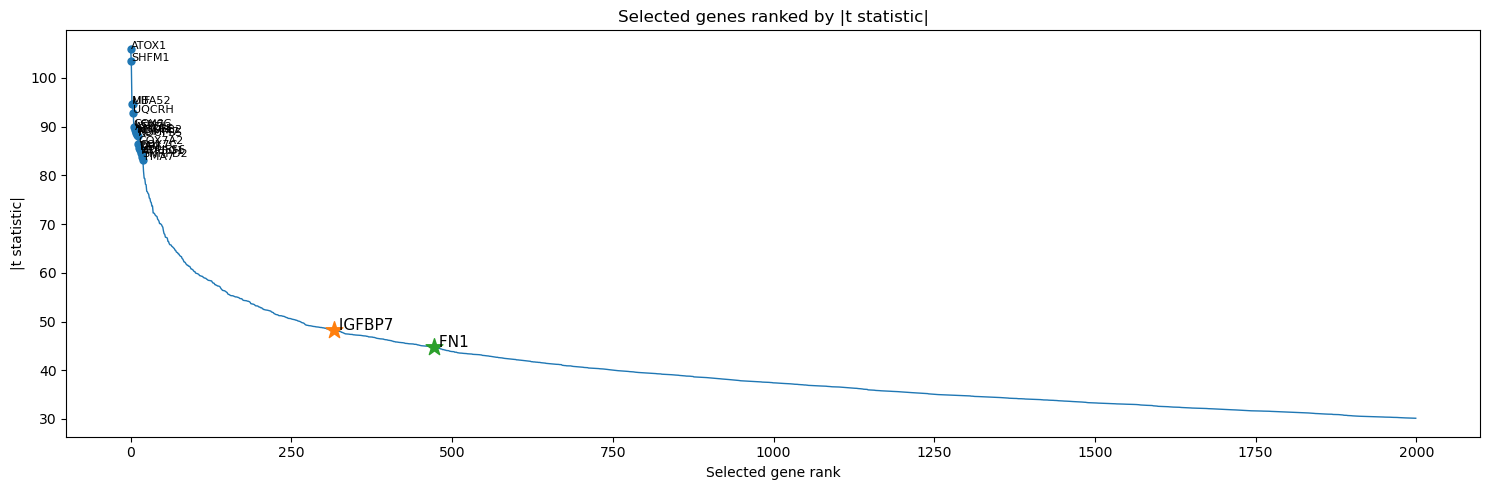

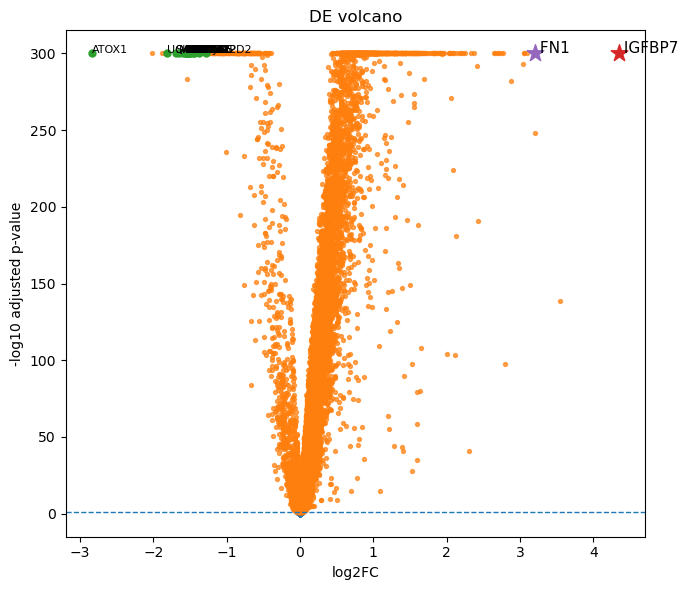

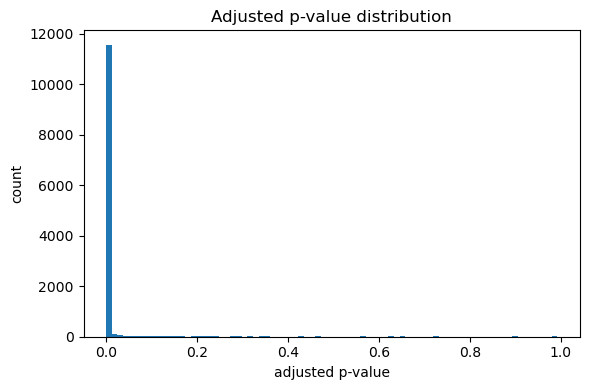

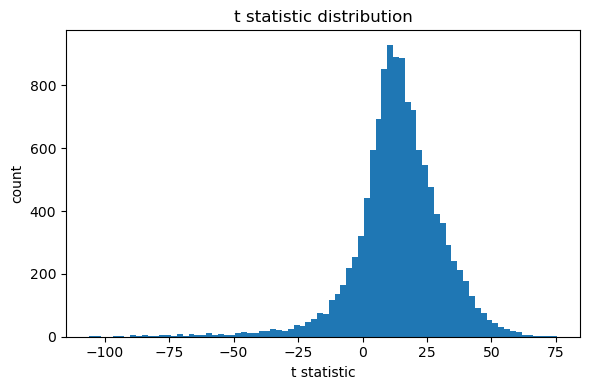

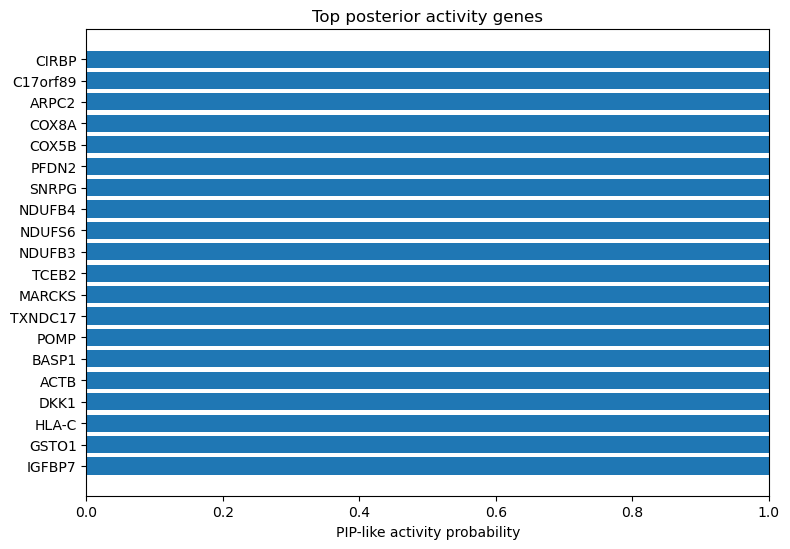

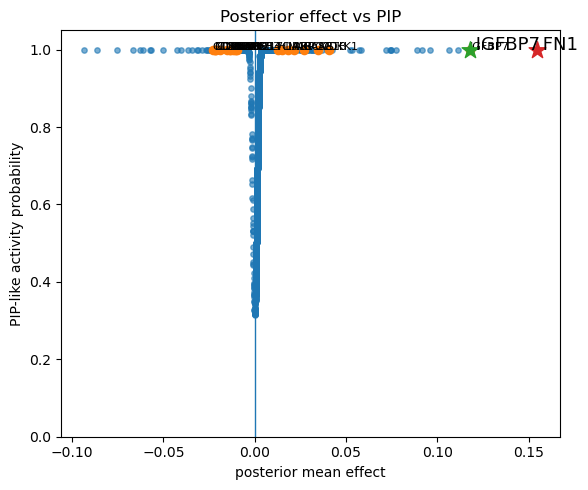

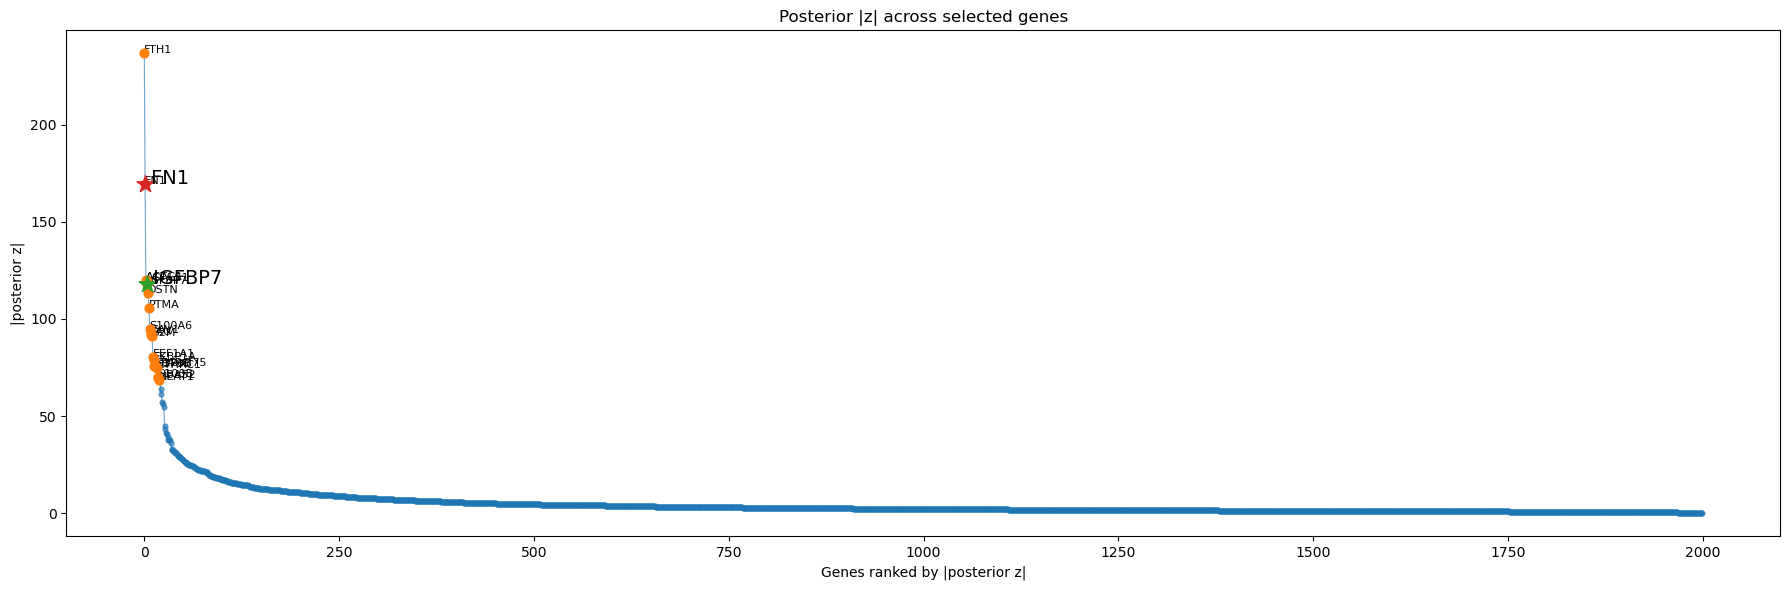

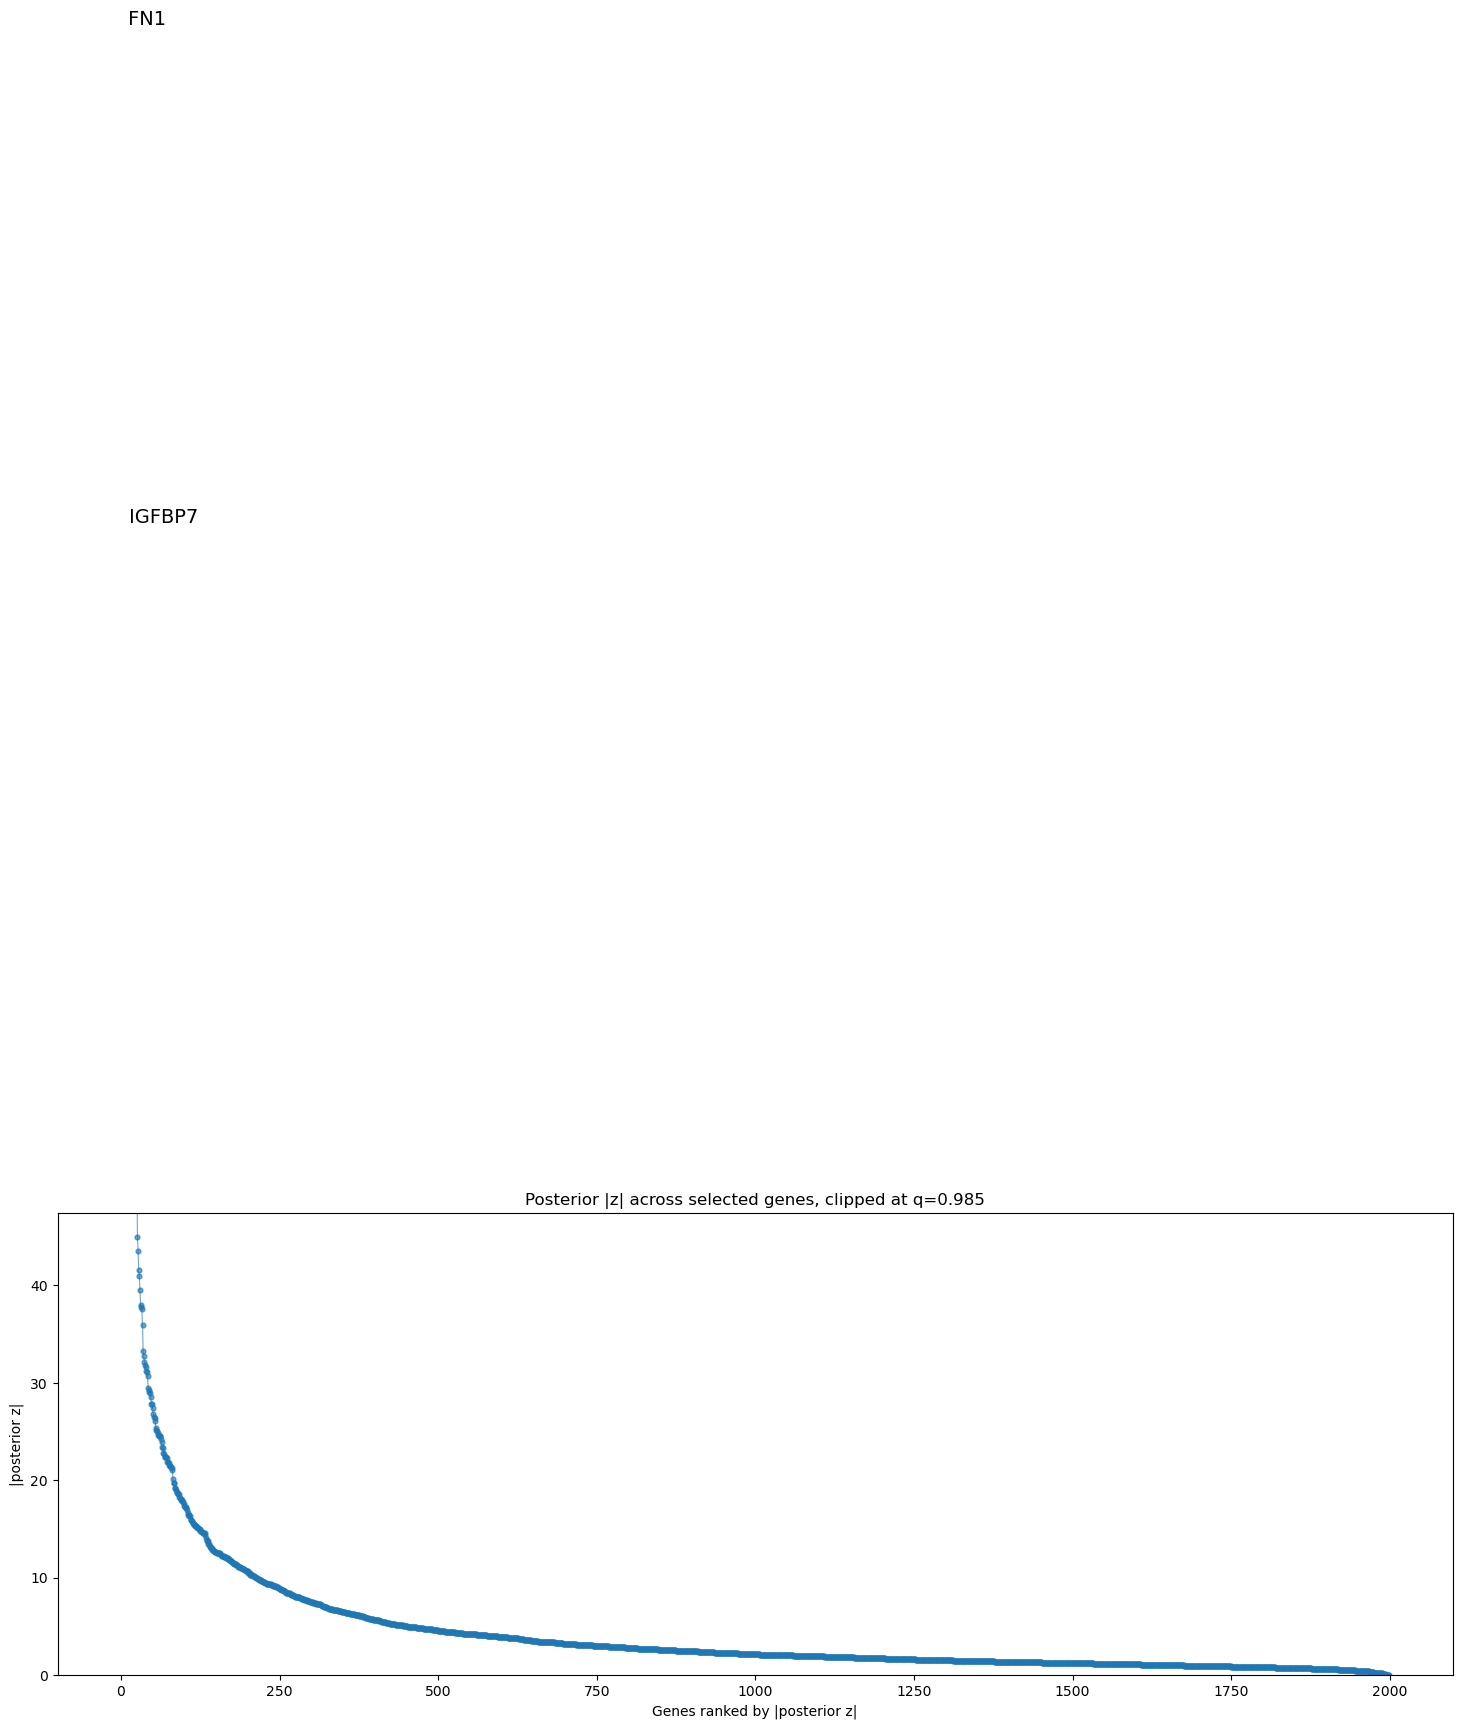

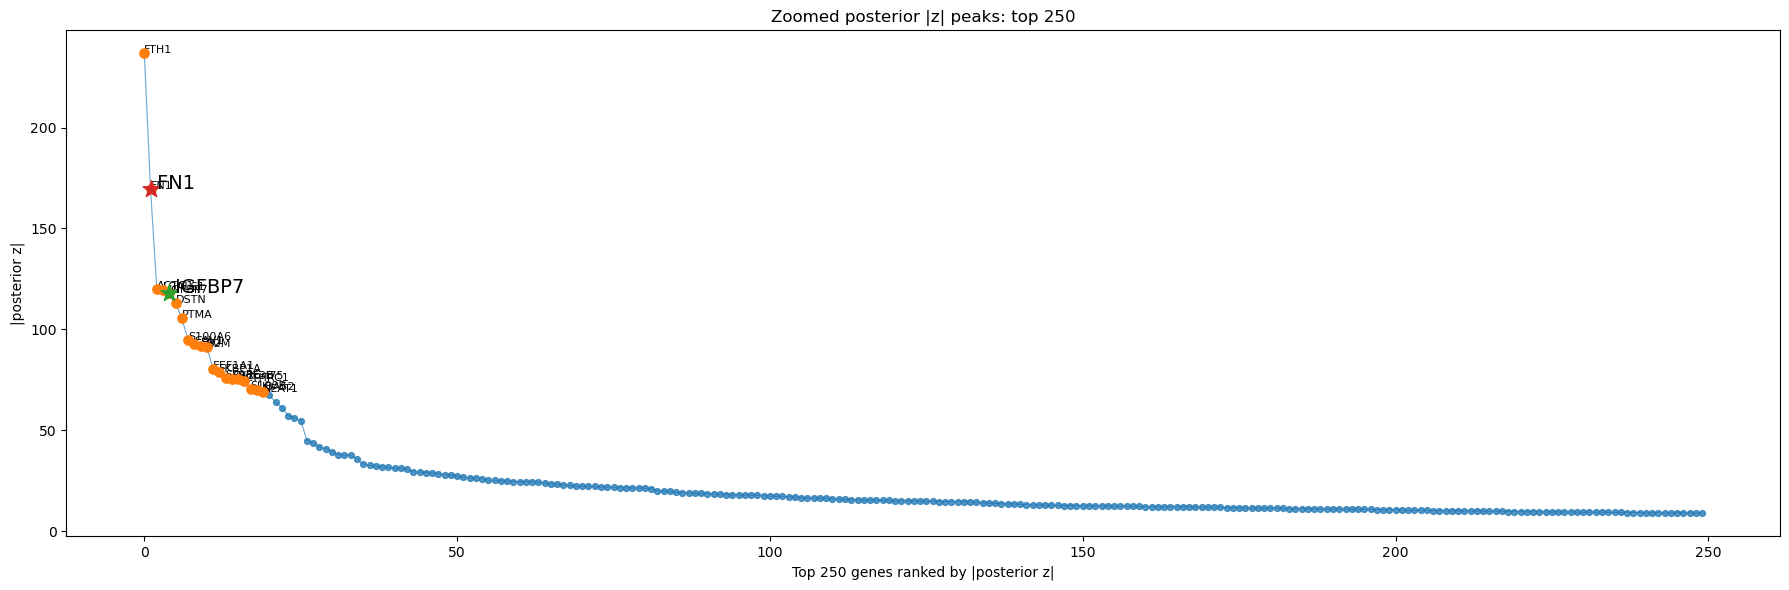

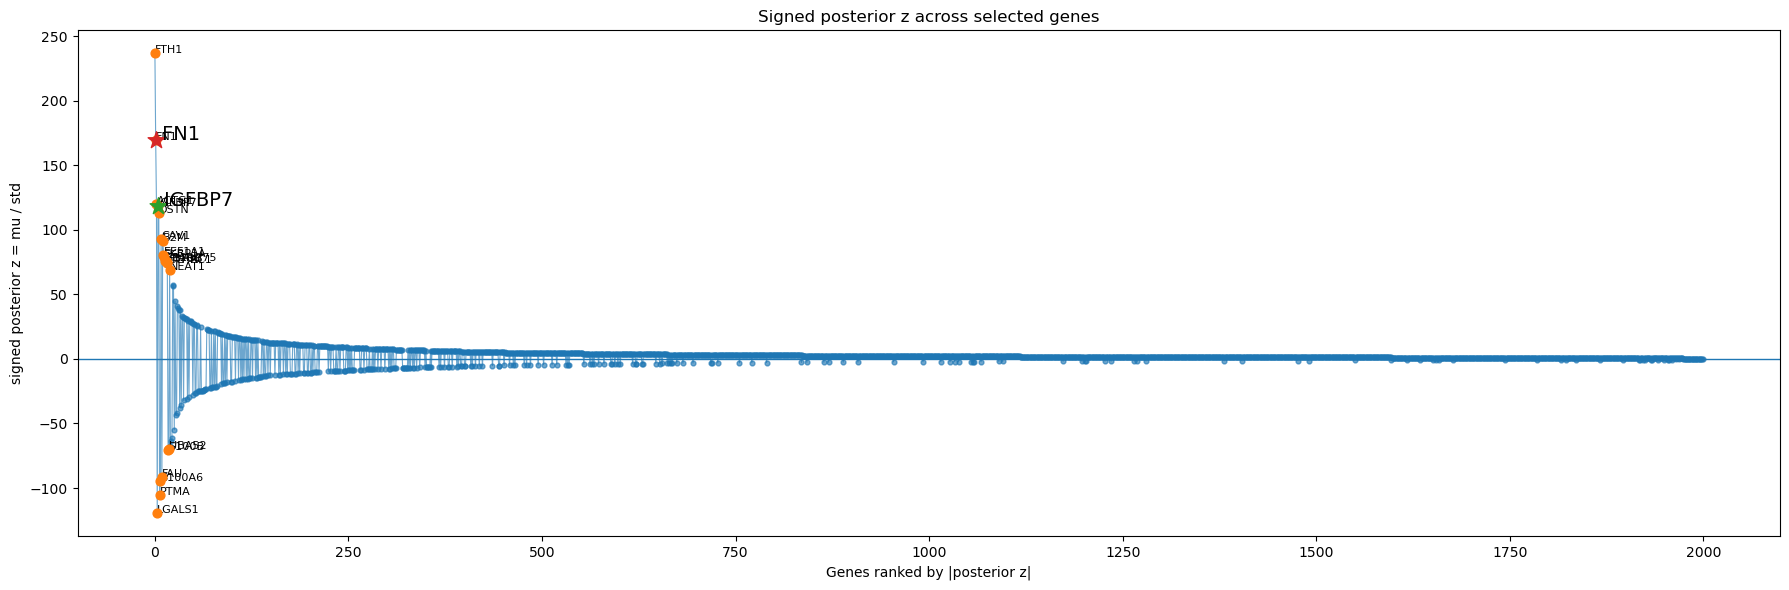

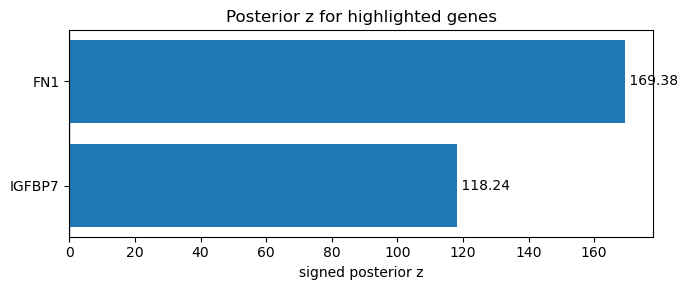

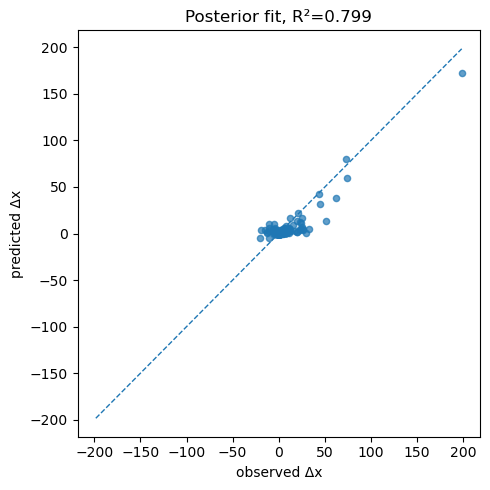

In [3]:
R.fit_analytic_posterior_pipeline()

### log(1+mu) vs rank (and signed variant), FN1/IGFBP7.

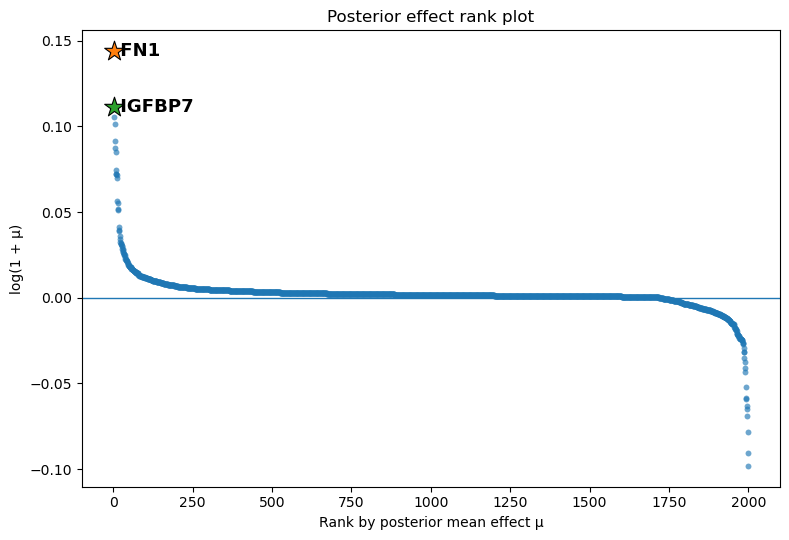

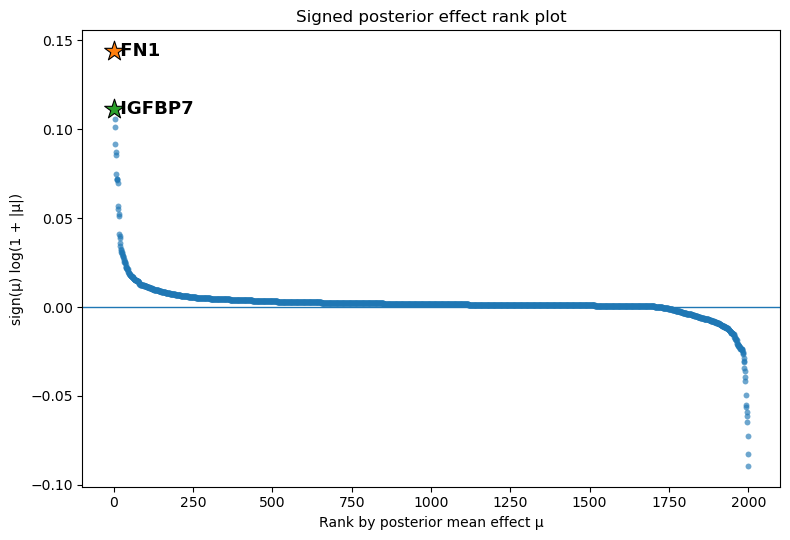

In [4]:
R.plot_log1p_mu_vs_rank()

### CIPHER score log(1+|mu|) vs |mu|-rank.

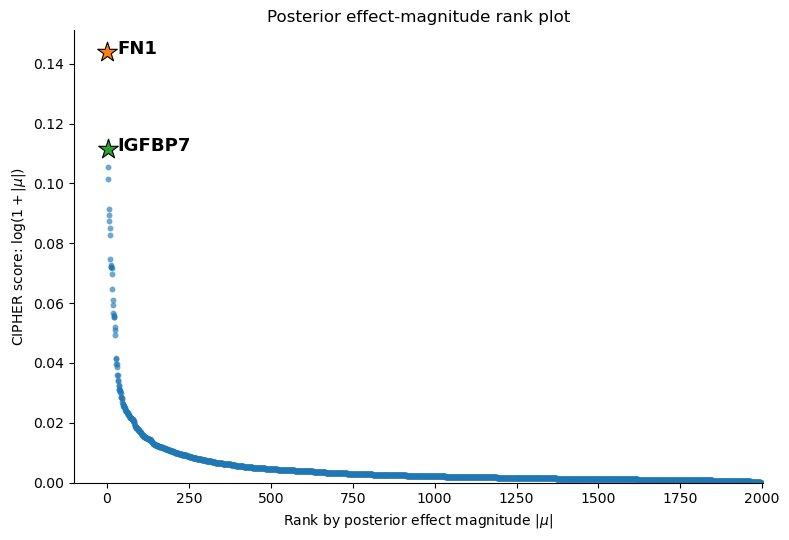

In [5]:
R.plot_cipher_score_vs_rank()

### CIPHER score vs rank with off-curve labels + LFC/CIPHER comparison table.

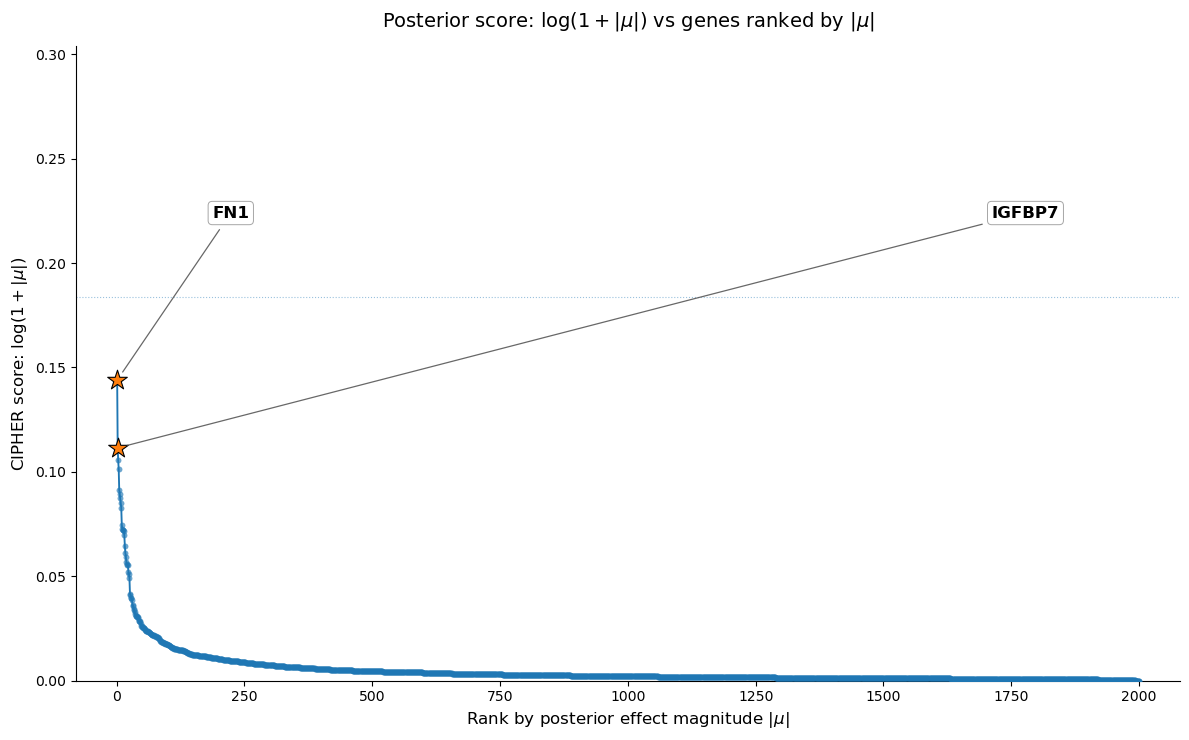

In [6]:
R.plot_cipher_rank_offcurve_labels()

### Naive control-cell mean expression ranked across all genes.

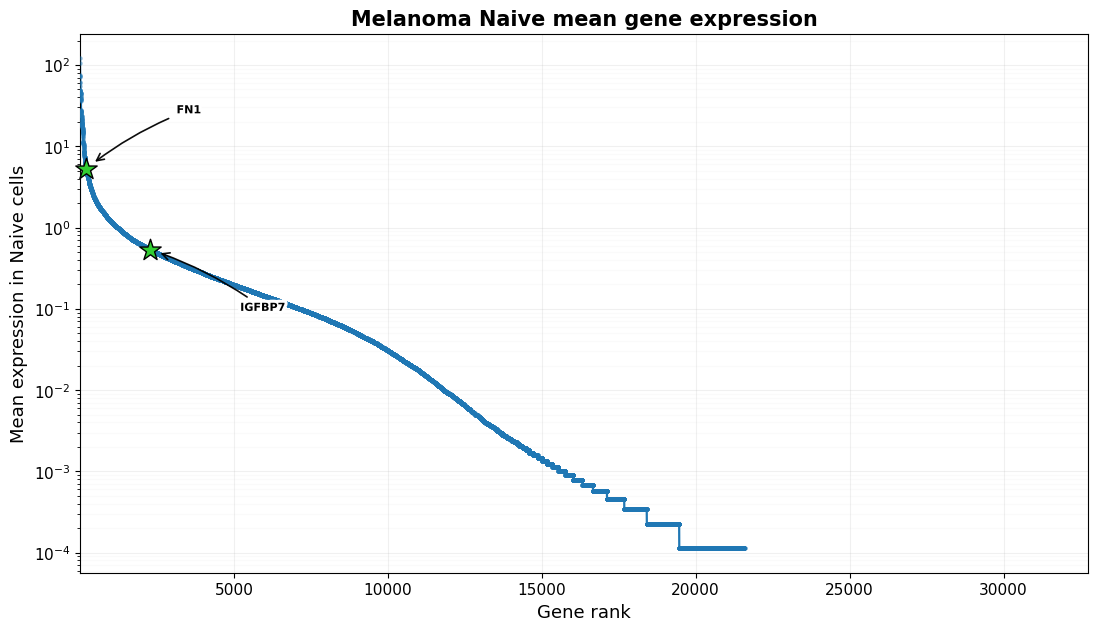

In [7]:
R.plot_naive_control_mean_expression()

### CIPHER rank plot with green/grey highlight groups.

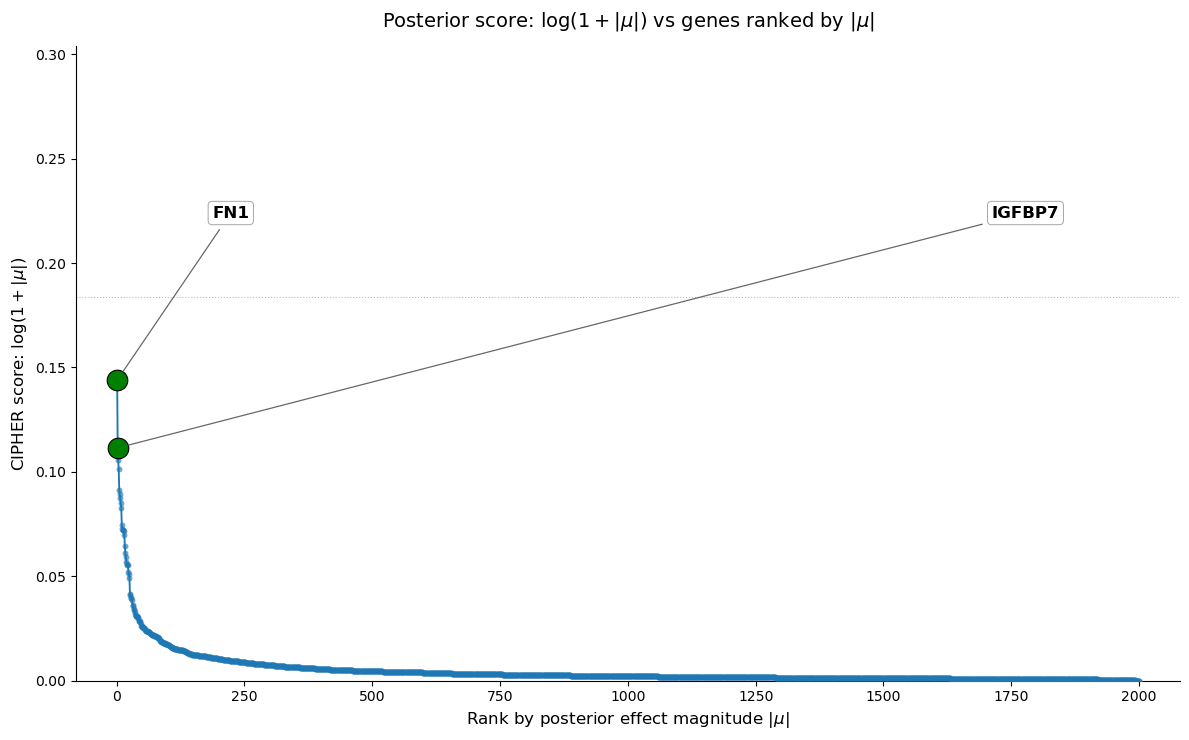

In [8]:
R.plot_cipher_rank_highlight_groups()

### Full-gene LFC vs CIPHER ranking table (load-or-recompute).

In [9]:
R.build_lfc_cipher_table()

### Posterior rank vs LFC rank; log(1+mu) vs log2FC.

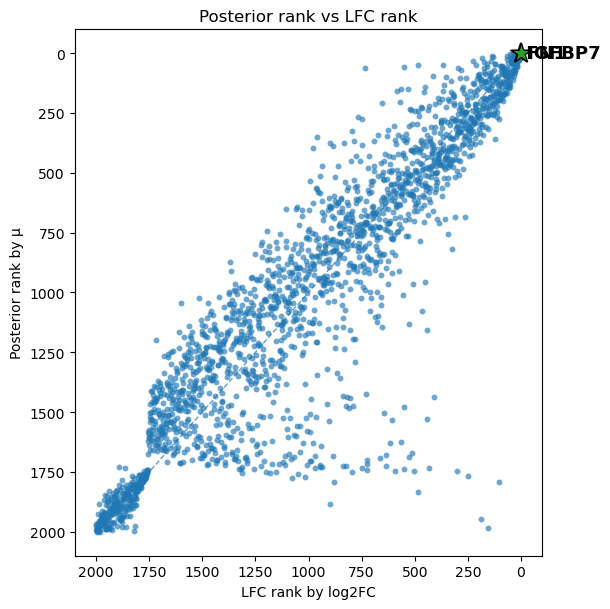

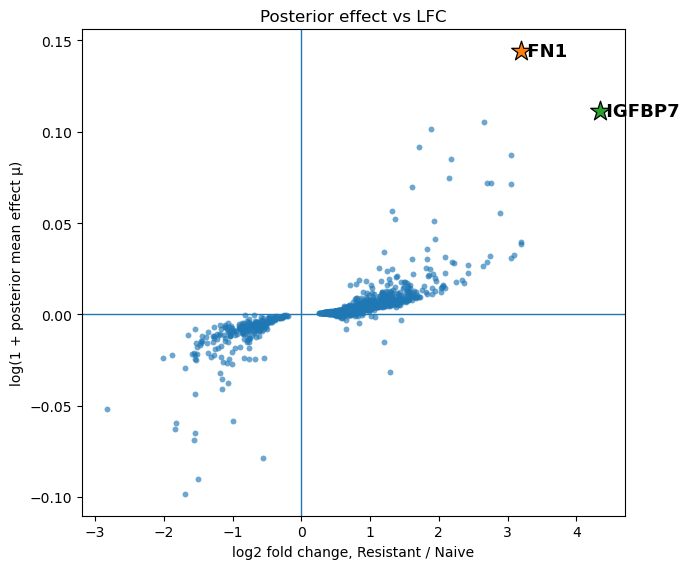

In [10]:
R.plot_posterior_vs_lfc_rank()

### log1p(mu) vs mu-rank and |z| vs mu-rank plots.

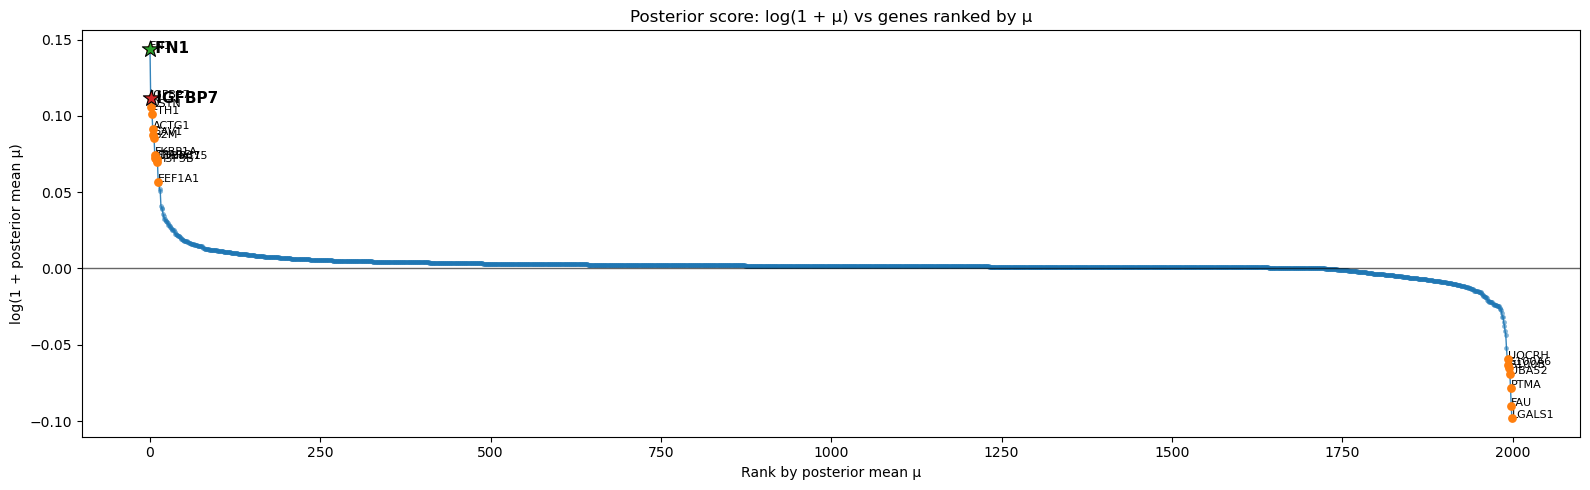

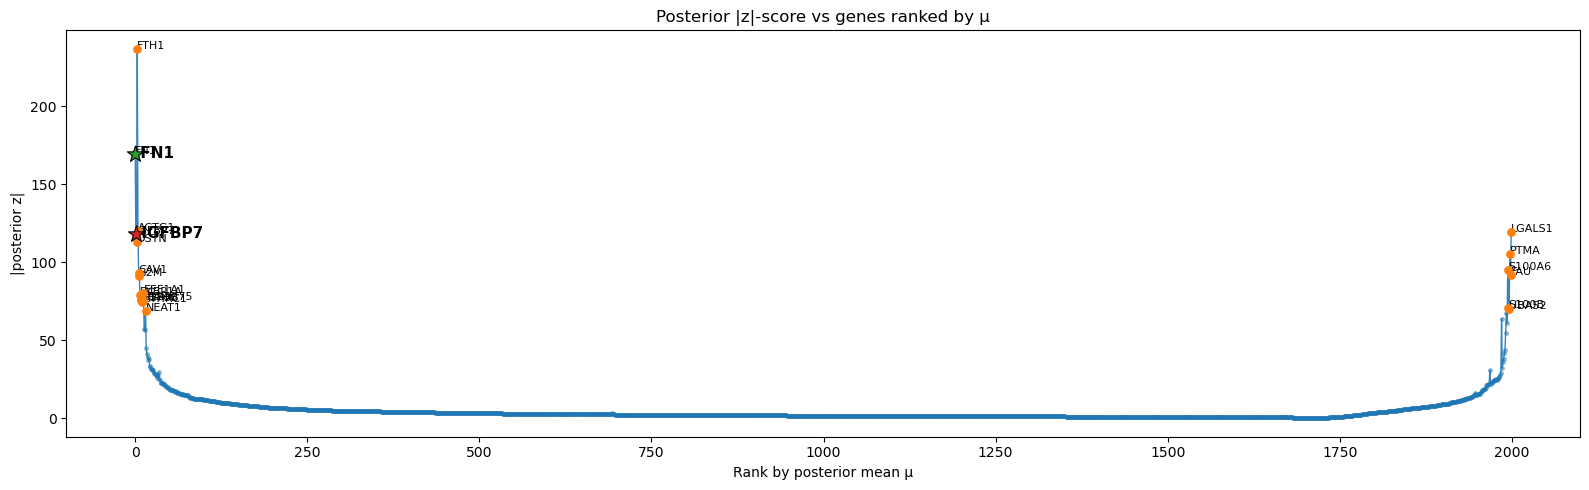

In [11]:
R.plot_log1p_mu_and_absz()

### Inspect four-conditions balanced file (condition counts).

In [12]:
R.inspect_four_conditions()

### UMAP of FN1/IGFBP7 (BC50 clone-size>1 dataset).

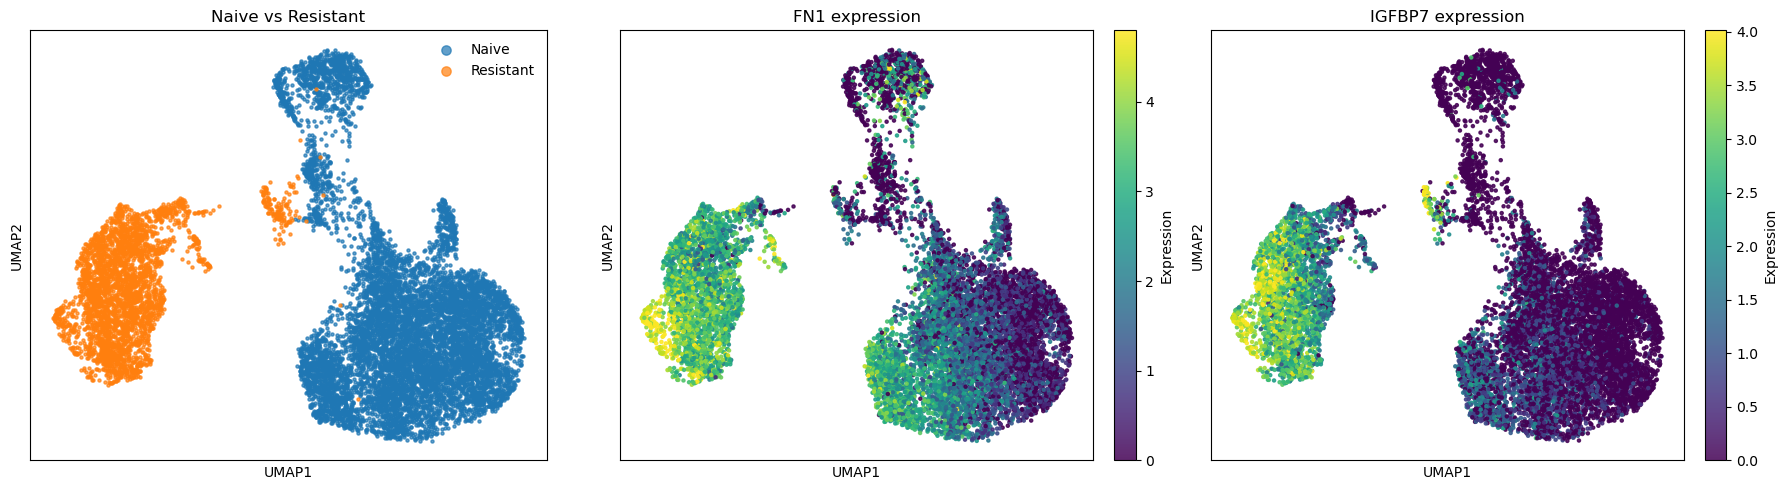

In [13]:
# The BC50 clone-size>1 h5ad is an author-derived subset NOT distributed in
# $CIPHER_DATA_DIR (only the melanoma-unbalanced and four-conditions objects are
# present); guard so the notebook runs on the available data instead of raising.
if os.path.exists(BC50_H5AD):
    R.umap_fn1_igfbp7_bc50()
else:
    print(
        "[skip] BC50 clone-size>1 dataset not present at:\n"
        f"       {BC50_H5AD}\n"
        "       author-derived subset absent from $CIPHER_DATA_DIR; skipping the BC50 UMAP."
    )

### UMAP of FN1/IGFBP7 (melanoma unbalanced dataset).

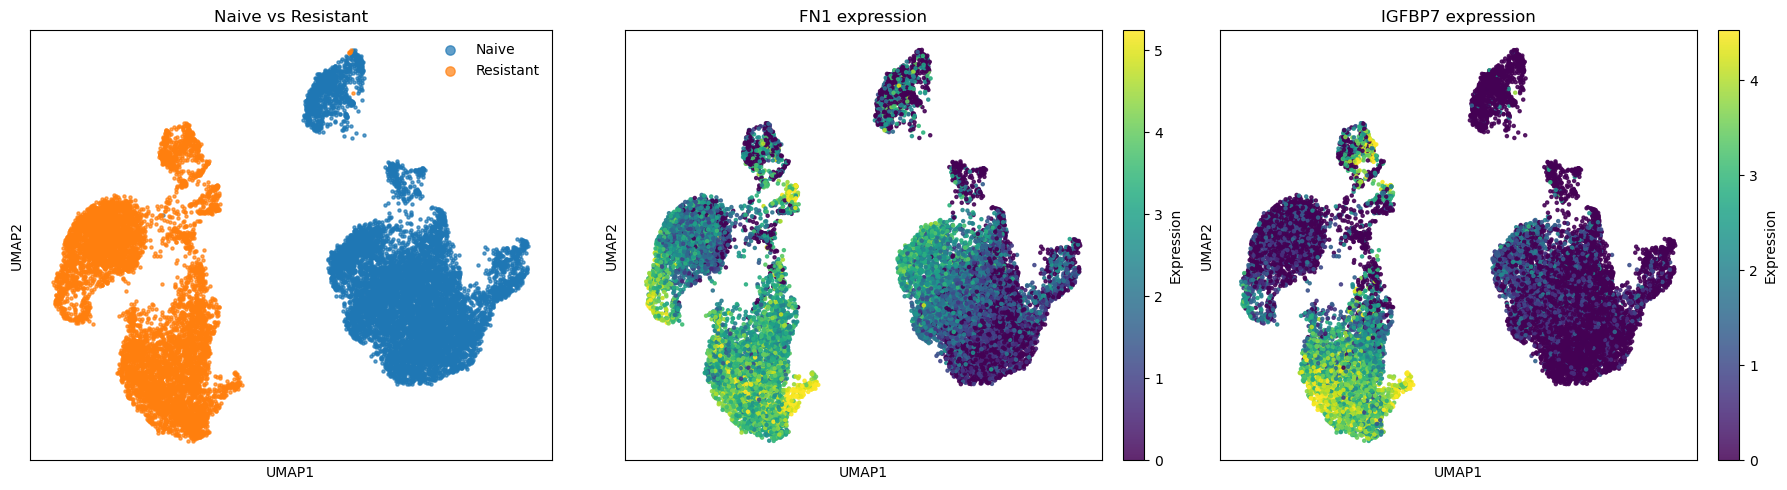

In [14]:
R.umap_fn1_igfbp7_melanoma()

### UMAP of FN1/IGFBP7 (variant).

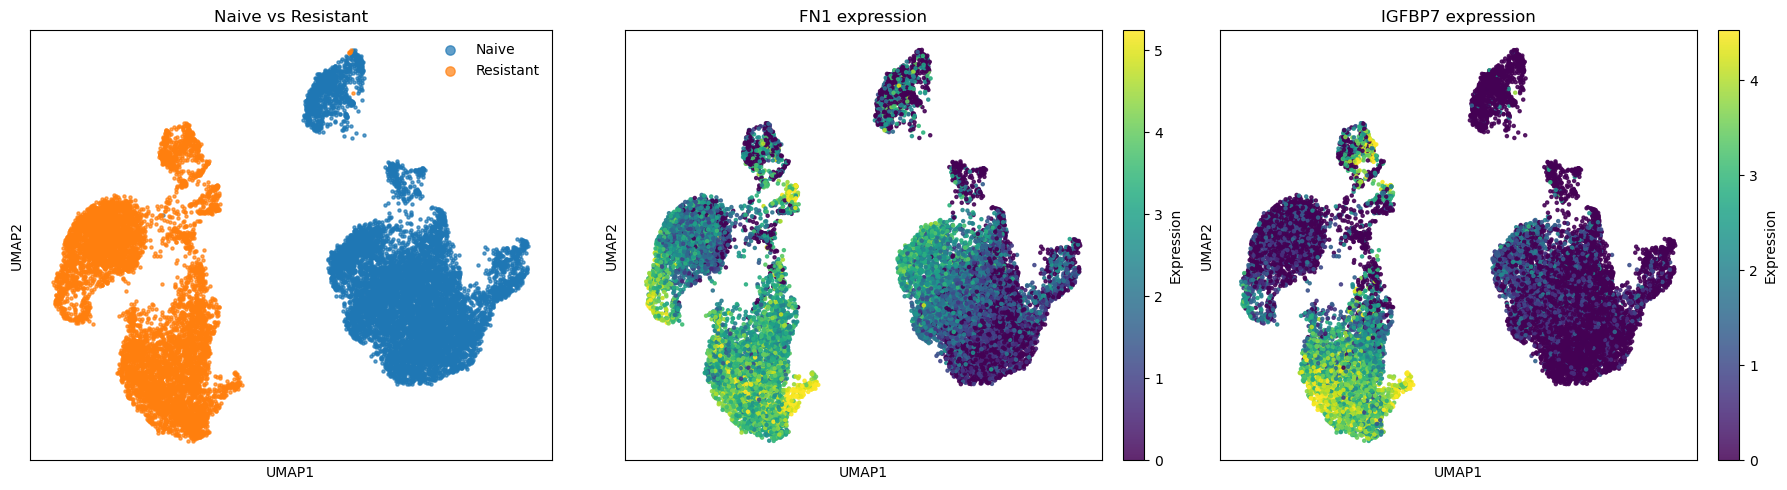

In [15]:
R.umap_fn1_igfbp7_variant()

### All-genes Welch DE volcano (BC50 dataset).

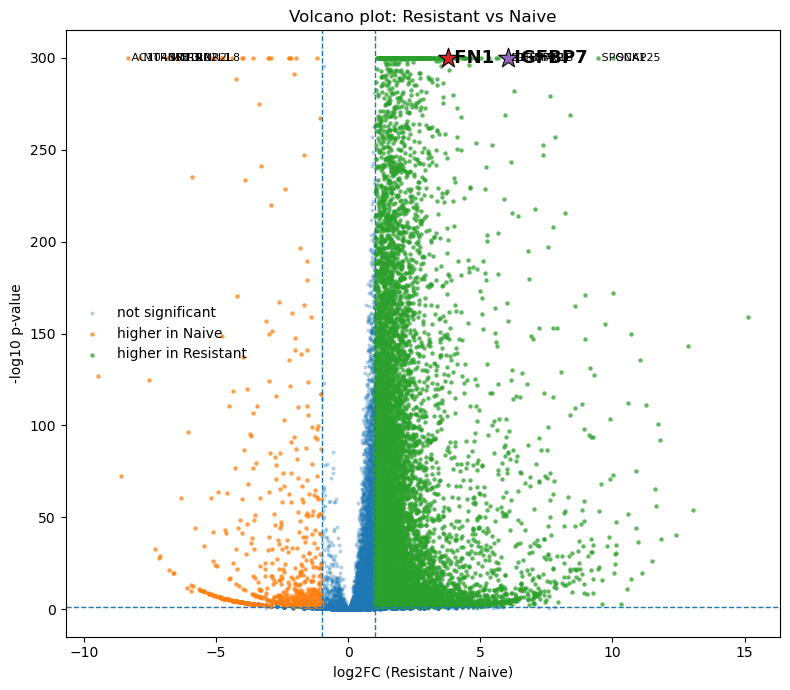

In [16]:
# The BC50 clone-size>1 h5ad is an author-derived subset NOT distributed in
# $CIPHER_DATA_DIR (only the melanoma-unbalanced and four-conditions objects are
# present); guard so the notebook runs on the available data instead of raising.
if os.path.exists(BC50_H5AD):
    R.volcano_bc50_allgenes()
else:
    print(
        "[skip] BC50 clone-size>1 dataset not present at:\n"
        f"       {BC50_H5AD}\n"
        "       author-derived subset absent from $CIPHER_DATA_DIR; skipping the BC50 all-genes volcano."
    )